In [1]:
import litminion as lm

/Users/rebeccasessa/miniforge3/envs/litminion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
lm.set_email("rebecca.sessa@studio.unibo.it")

In [3]:
corpus = lm.Corpus.from_pubmed(
    query="JAK inhibitor",
    max_results=20,
)

corpus

Corpus(documents=19, processed=False, columns=7)

In [4]:
preprocessor = lm.ClassicalPreprocessor()

corpus.preprocess(preprocessor)

corpus

Corpus(documents=19, processed=True, columns=7)

In [5]:
corpus.get_documents()[:2]

['give active role JAK signal pathway multifactorial immune mediator observe Behçet syndrome BS JAK inhibitor JAKi promise agent systematic literature review SLR aim evaluate efficacy safety JAKi BS systematic literature search conduct Embase PubMed Cochrane Library identify report efficacy safety JAKi patient BS SLR protocol register International Prospective Registry Systematic Reviews CRD420251000172 additionally present patient gastrointestinal involvement treat upadacitinib patient man mean SD age year tofacitinib baricitinib upadacitinib patient previous conventional immunosuppressive refractory prior tumor necrosis factor inhibitor JAKi combination conventional immunosuppressive and/or glucocorticoid patient primary indication JAKi initiation gastrointestinal involvement patient include patient vascular involvement uveitis mucocutaneous and/or articular involvement patient remission rate overall gastrointestinal vascular eye involvement adverse event observe patient thrombotic e

In [6]:
extractor = lm.KeyBERTKeywordExtractor()

extractor

KeyBERTKeywordExtractor(documents=0, fitted=False)

In [7]:
extractor.fit(
    corpus.get_documents()
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9352.76it/s]


KeyBERTKeywordExtractor(documents=19, fitted=True)

In [8]:
extractor

KeyBERTKeywordExtractor(documents=19, fitted=True)

In [9]:
len(extractor)

19

In [27]:
keywords = extractor.transform()

type(keywords)

list

In [11]:
len(keywords)

19

In [12]:
extractor.get_keywords(
    document=0,
    n=10,
)

[('jaki patient', 0.5463),
 ('jak inhibitor', 0.533),
 ('inhibitor jaki', 0.5168),
 ('indication jaki', 0.427),
 ('jaki initiation', 0.4234),
 ('jaki effective', 0.4061),
 ('role jak', 0.4047),
 ('show jaki', 0.4031),
 ('jaki combination', 0.4021),
 ('immunosuppressive', 0.3957)]

In [13]:
extractor.get_keywords(
    document=1,
    n=10,
)

[('ocular sarcoidosis', 0.6651),
 ('sarcoid uveitis', 0.6096),
 ('present panuveitis', 0.5757),
 ('panuveitis require', 0.5532),
 ('sarcoidosis frequent', 0.5488),
 ('posterior panuveitis', 0.5379),
 ('manifestation sarcoidosis', 0.5303),
 ('sarcoidosis occur', 0.5226),
 ('panuveitis', 0.522),
 ('sarcoidosis', 0.521)]

In [14]:
extractor.to_dataframe(
    document=0,
    n=10,
)

,Keyword,Score
0,jaki patient,0.5463
1,jak inhibitor,0.5330
2,inhibitor jaki,0.5168
3,indication jaki,0.4270
4,jaki initiation,0.4234
5,jaki effective,0.4061
6,role jak,0.4047
7,show jaki,0.4031
8,jaki combination,0.4021
9,immunosuppressive,0.3957


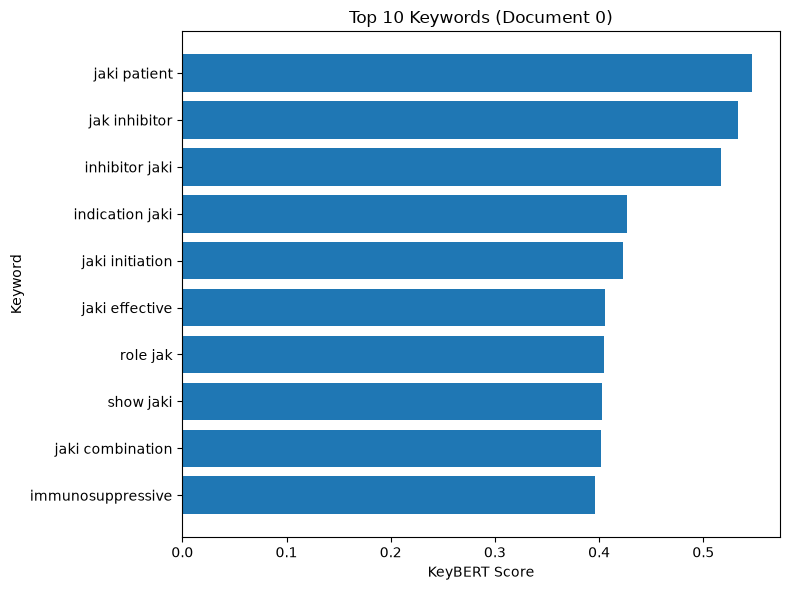

<Axes: title={'center': 'Top 10 Keywords (Document 0)'}, xlabel='KeyBERT Score', ylabel='Keyword'>

In [15]:
extractor.plot(
    document=0,
    n=10,
)

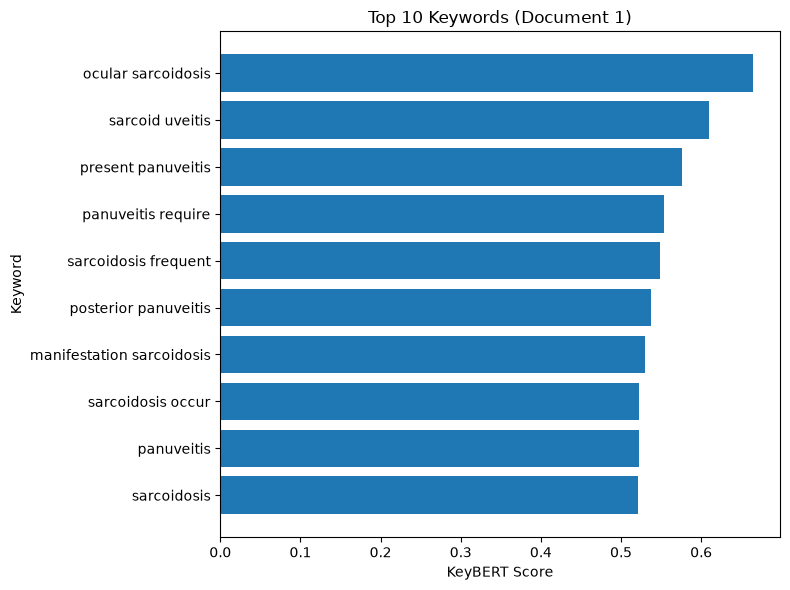

<Axes: title={'center': 'Top 10 Keywords (Document 1)'}, xlabel='KeyBERT Score', ylabel='Keyword'>

In [16]:
extractor.plot(
    document=1,
    n=10,
)

In [17]:
print(corpus.data.loc[0, "Title"])

Efficacy and safety of JAK inhibitors in Behçet syndrome: systematic literature review.


In [18]:
extractor.get_keywords(
    document=0,
    n=10,
)

[('jaki patient', 0.5463),
 ('jak inhibitor', 0.533),
 ('inhibitor jaki', 0.5168),
 ('indication jaki', 0.427),
 ('jaki initiation', 0.4234),
 ('jaki effective', 0.4061),
 ('role jak', 0.4047),
 ('show jaki', 0.4031),
 ('jaki combination', 0.4021),
 ('immunosuppressive', 0.3957)]

In [19]:
print(corpus.data.loc[5, "Title"])

Advanced therapies in management of pediatric inflammatory bowel disease.


In [20]:
extractor.get_keywords(
    document=5,
    n=10,
)

[('pediatric inflammatory', 0.4933),
 ('inflammatory bowel', 0.4178),
 ('bowel disease', 0.4117),
 ('colitis emerge', 0.4102),
 ('ulcerative colitis', 0.3945),
 ('crohn disease', 0.3823),
 ('colitis', 0.3654),
 ('pediatric clinical', 0.3654),
 ('advanced biologic', 0.362),
 ('access therapeutic', 0.3525)]

In [21]:
keywords = extractor.transform()

keywords[0]

[('jaki patient', 0.5463),
 ('jak inhibitor', 0.533),
 ('inhibitor jaki', 0.5168),
 ('indication jaki', 0.427),
 ('jaki initiation', 0.4234),
 ('jaki effective', 0.4061),
 ('role jak', 0.4047),
 ('show jaki', 0.4031),
 ('jaki combination', 0.4021),
 ('immunosuppressive', 0.3957),
 ('jaki bs', 0.3868),
 ('immunosuppressive and', 0.3859),
 ('jaki', 0.3767),
 ('jak', 0.3762),
 ('upadacitinib patient', 0.3712),
 ('jak signal', 0.3626),
 ('conventional immunosuppressive', 0.3608),
 ('safety jaki', 0.3604),
 ('bs jak', 0.3471),
 ('patient primary', 0.3316)]

In [22]:
try:
    extractor.get_keywords(
        document=100,
    )

except Exception as e:

    print(type(e).__name__)
    print(e)

IndexError
Document index 100 is out of range. The corpus contains 19 documents.


In [23]:
try:
    extractor.get_keywords(
        document=0,
        n=0,
    )

except Exception as e:

    print(type(e).__name__)
    print(e)

ValueError
'n' must be greater than zero.


In [24]:
empty = lm.KeyBERTKeywordExtractor()

try:
    empty.transform()

except Exception as e:

    print(type(e).__name__)
    print(e)

ValueError
The keyword extractor has not been fitted. Call 'fit()' or 'fit_transform()' first.


In [25]:
try:
    empty.get_keywords()

except Exception as e:

    print(type(e).__name__)
    print(e)

ValueError
The keyword extractor has not been fitted. Call 'fit()' or 'fit_transform()' first.


In [26]:
for i in range(5):

    print("=" * 80)

    print(corpus.data.loc[i, "Title"])

    print()

    for keyword, score in extractor.get_keywords(i, 10):

        print(f"{keyword:<35} {score:.3f}")

    print()

Efficacy and safety of JAK inhibitors in Behçet syndrome: systematic literature review.

jaki patient                        0.546
jak inhibitor                       0.533
inhibitor jaki                      0.517
indication jaki                     0.427
jaki initiation                     0.423
jaki effective                      0.406
role jak                            0.405
show jaki                           0.403
jaki combination                    0.402
immunosuppressive                   0.396

Ocular sarcoidosis: from clinical signs to targeted interventions.

ocular sarcoidosis                  0.665
sarcoid uveitis                     0.610
present panuveitis                  0.576
panuveitis require                  0.553
sarcoidosis frequent                0.549
posterior panuveitis                0.538
manifestation sarcoidosis           0.530
sarcoidosis occur                   0.523
panuveitis                          0.522
sarcoidosis                         0.521

F